# 2 - Training U-Net for Gap-Filling (Generic - Streaming)

**Self-supervised streaming training pipeline** for any Level-3 ocean variable.

This notebook trains a U-Net to fill gaps in satellite ocean observations using **xbatcher streaming** to keep memory bounded. Works for:
- Chlorophyll-a (PACE, Copernicus, CMEMS)
- Sea surface temperature
- Any other gridded ocean variable with cloud/missing data

## Key Features

- **Streaming workflow**: Zarr → xarray/Dask → xbatcher → TensorFlow
- **Memory-bounded**: Never loads full dataset into RAM
- **Spatial chunking**: 40×56 tiles (or configurable)
- **Generic target variable**: Not hardcoded to chlorophyll
- **Self-supervised**: No gap-free truth needed  
- **Synthetic clouds**: Temporally-correlated fake gaps for training/eval

## Workflow

```
Zarr (on-disk)
  ↓ xr.open_zarr with chunks
Lazy xarray/Dask Dataset
  ↓ build_standardized_lazy (no .load())
Lazy standardized channels
  ↓ xbatcher.BatchGenerator
Spatial tiles (time × 40×56)
  ↓ make_tf_gen → tf.data.Dataset
Training batches
  ↓
model.fit()
```

## Setup

In [59]:
# Import the local checkout when running this notebook from the repository.
import sys
from pathlib import Path

for parent in (Path.cwd(), Path.cwd().parent):
    if (parent / "mindthegap").is_dir():
        sys.path.insert(0, str(parent))
        break

# 1 = PACE, 2 = GlobColour, 3 = IO, 4 = deterministic demo
dataset = 2

# Keep remote validation runs small. Set False for full training.
SMOKE_TEST = True
SMOKE_DAYS = 120
SMOKE_SPATIAL_SIZE = 64*2

In [23]:
# Icechunk is only required by the PACE and GlobColour loaders.
if dataset in (1, 2):
    get_ipython().run_line_magic("pip", "install -q 'icechunk>=2'")

Note: you may need to restart the kernel to use updated packages.


In [24]:
if dataset in (1, 2):
    import icechunk

    icechunk_major = int(icechunk.__version__.split(".", 1)[0])
    if icechunk_major < 2:
        raise RuntimeError("PACE and GlobColour require icechunk >= 2")
    print(f"Icechunk version: {icechunk.__version__}")

Icechunk version: 2.1.2


In [6]:
# Earthaccess is only required by the authenticated PACE loader.
if dataset == 1:
    get_ipython().run_line_magic("pip", "install -q 'earthaccess>=0.15'")

In [7]:
if dataset == 1:
    import earthaccess
    from packaging.version import Version

    if Version(earthaccess.__version__) < Version("0.15"):
        raise RuntimeError("PACE requires earthaccess >= 0.15")
    print(f"Earthaccess version: {earthaccess.__version__}")

In [25]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # Reduce TensorFlow verbosity

import numpy as np
import pandas as pd
import xarray as xr
import tensorflow as tf
import matplotlib.pyplot as plt
import mindthegap as mtg

# TensorFlow automatically uses CPU when no GPU is available.
gpus = tf.config.list_physical_devices("GPU")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

print(f"TensorFlow version: {tf.__version__}")
print(f"Compute device: {'GPU' if gpus else 'CPU'}")
print(f"GPUs available: {len(gpus)}")

TensorFlow version: 2.19.1
Compute device: GPU
GPUs available: 1


## 1. Load Your Data

Load your xarray Dataset with **time, lat, lon** dimensions.

### Requirements:
- Target variable (e.g., `chlor_a`, `sst`, `analysed_sst`)
- Cloud/missing flag variable (1 = cloud/missing, 0 = valid data)
- Land flag variable (1 = land, 0 = ocean)
- Optional: Additional predictor variables (SST, winds, salinity, etc.)

### Data Source Examples:

In [26]:
dataset_names = {1: "PACE", 2: "GlobColour", 3: "IO", 4: "demo"}
if dataset not in dataset_names:
    raise ValueError(f"Unknown dataset selection: {dataset}")
print(f"Selected dataset: {dataset_names[dataset]}")

Selected dataset: GlobColour


In [ ]:
# Example 1: PACE Chlorophyll (AWS us-west-2 required)
if dataset == 1:
    import earthaccess
    import icechunk as ic
    
    def load_pace_chl(lat_slice, lon_slice):
        auth = earthaccess.login()
        creds = auth.get_s3_credentials(daac="OBDAAC")
        
        url = "https://data.source.coop/fish-pace/pace-oci/inregion/PACE_OCI_L3M_CHL"
        storage = ic.http_storage(url)
        vc = ic.credentials.containers_credentials({
            "s3://ob-cumulus-prod-public/": ic.credentials.s3_credentials(
                access_key_id=creds["accessKeyId"],
                secret_access_key=creds["secretAccessKey"],
                session_token=creds["sessionToken"]
            )
        })
        
        store = ic.Repository.open(storage, authorize_virtual_chunk_access=vc).readonly_session("main").store
        ds = xr.open_zarr(store, consolidated=False, group="daily/0p1deg/chunks_512", chunks={})
        ds = ds.sel(lat=lat_slice, lon=lon_slice)
        
        # Derive land and cloud flags (PACE doesn't have explicit flags)
        gap = ds['chlor_a'].isnull()
        land = gap.all(dim='time')
        ds['land_flag'] = land.astype('int8')
        ds['cloud_flag'] = (gap & ~land).astype('int8')
        
        return ds
    
    ds = load_pace_chl(lat_slice=slice(31, 5), lon_slice=slice(42, 80))
    target_var = 'chlor_a'
    feature_vars = []
    missing_flag_var = 'cloud_flag'
    land_flag_var = 'land_flag'

In [43]:
# Example 2: Copernicus GlobColour (via icechunk)
# use this example. Needs icechunk > 2
if (dataset == 2):
    import icechunk as ic
    import xarray as xr
    
    def open_globcolour(lat_slice, lon_slice):
        """Open a spatial subset as a Dask-backed xarray Dataset."""
        url = "https://data.source.coop/fish-pace/globcolour/cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
        storage = ic.http_storage(url)
        repo = ic.Repository.open(storage)
        auth = {
            prefix: ic.credentials.HttpAccess
            for prefix in repo.config.virtual_chunk_containers or []
        }
        store = repo.reopen(
            authorize_virtual_chunk_access=auth
        ).readonly_session("main").store
    
        ds = xr.open_zarr(store, consolidated=False, chunks={})
        ds = ds[["CHL", "flags"]].sel(lat=lat_slice, lon=lon_slice)
        ds["land_flag"] = (ds["flags"] == 1).astype("int8")
        ds["cloud_flag"] = (
            ds["CHL"].isnull() & (ds["land_flag"] == 0)
        ).astype("int8")
        ds = ds.drop_vars("flags")
    
        return ds
    
    ds = open_globcolour(lat_slice=slice(31, 5), lon_slice=slice(42, 80))
    
    target_var = 'CHL'
    feature_vars = []  # e.g., ['sst', 'u_wind', 'v_wind', 'air_temp']
    missing_flag_var = 'cloud_flag'
    land_flag_var = 'land_flag'


/srv/conda/envs/notebook/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:141: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


In [ ]:
# Example 3: IO (Google Cloud Storage)
if (dataset == 3):
    ds = xr.open_dataset(
        "gcs://nmfs_odp_nwfsc/CB/mind_the_chl_gap/IO_rechunked.zarr",
        engine="zarr",
        backend_kwargs={"storage_options": {"token": "anon"}},
        consolidated=True
    )
    ds = ds.sel(lat=slice(31, 5), lon=slice(42, 80))
    
    target_var = 'CHL_cmes-level3'
    feature_vars = []  # e.g., ['sst', 'u_wind', 'v_wind', 'air_temp']
    missing_flag_var = 'CHL_cmes-cloud'
    land_flag_var = 'CHL_cmes-land'


In [ ]:
# Example 4: Demo data
if dataset == 4:
    ds = mtg.demo_data(days=120, lat_size=16, lon_size=16, seed=42)
    
    # Specify your variable names
    target_var = "chlor_a"  # Variable to gap-fill
    feature_vars = []  # e.g., ['sst', 'u_wind', 'v_wind', 'air_temp']
    missing_flag_var = "cloud_flag"  # 1 = missing/cloud, 0 = valid
    land_flag_var = "land_flag"  # 1 = land, 0 = ocean


In [44]:
# Smoke_Test

if SMOKE_TEST and dataset != 4:
    ds = ds.isel(
        time=slice(0, min(SMOKE_DAYS, ds.sizes["time"])),
        lat=slice(0, min(SMOKE_SPATIAL_SIZE, ds.sizes["lat"])),
        lon=slice(0, min(SMOKE_SPATIAL_SIZE, ds.sizes["lon"])),
    )
    print(f"Smoke-test subset: {dict(ds.sizes)}")

if dataset == 3:
    # IO flag value 2 is static land; compute the 2D mask from one day.
    land = ds["CHL_cmes-cloud"].isel(time=0) == 2
    ds["CHL_cmes-land"] = land.astype("int8").broadcast_like(
        ds["CHL_cmes-level3"]
    )

Smoke-test subset: {'time': 120, 'lat': 128, 'lon': 128}


## 2. Build Standardized Training data

Use `build_standardized_lazy()` to create standardized predictors **without loading data into memory**.

In [45]:
# Crop to U-Net-compatible dimensions (multiples of 8)
ds = mtg.crop_to_multiple(ds, multiple=8)

print(f"\nAfter cropping to multiple of 8:")
print(f"Dimensions: {dict(ds.sizes)}")


After cropping to multiple of 8:
Dimensions: {'time': 120, 'lat': 128, 'lon': 128}


In [46]:
# Preprocessing options
log_transform = True  # Apply log to target? (True for chlorophyll, False for SST)
n_temporal_lags = 1  # Number of prev/next day channels (1 = prev1, next1)

# Infer tile sizes from the source chunks, capped to control model memory.
def tile_size(dim, upper_limit=64, multiple=8):
    chunks = ds.chunksizes.get(dim, (ds.sizes[dim],))
    available = min(ds.sizes[dim], chunks[0], upper_limit)
    aligned = available - available % multiple
    if aligned < multiple:
        raise ValueError(f"{dim} must contain at least {multiple} cells")
    return aligned

TILE_LAT = tile_size("lat")
TILE_LON = tile_size("lon")
TIME_CHUNK = min(100, max(1, ds.sizes["time"] // 6))

# xbatcher limits each spatial tile; batch size limits how many tiles the
# model processes simultaneously. Keep their combined pixel count bounded.
pixels_per_tile = TILE_LAT * TILE_LON
BATCH_SIZE = max(1, min(16, (40 * 56 * 16) // pixels_per_tile))
short_run = ds.sizes["time"] <= 120
EPOCHS = 2 if short_run else 50
PATIENCE = 2 if short_run else 10

# Use a 50/25/25 split for short datasets and 3/1/rest years otherwise.
train_start = str(pd.to_datetime(ds.time.values[0]).date())
if short_run:
    train_days = ds.sizes["time"] // 2
    val_days = ds.sizes["time"] // 4
else:
    train_days = 3 * 365
    val_days = 365
train_end_date = pd.to_datetime(ds.time.values[0]) + pd.DateOffset(days=train_days)
val_end_date = train_end_date + pd.DateOffset(days=val_days)

# =============================================================================

print(f"Dataset dimensions: {dict(ds.sizes)}")
print(f"Target variable: {target_var}")
print(f"Date range: {pd.to_datetime(ds.time.values[0])} to {pd.to_datetime(ds.time.values[-1])}")

print(f"Training period: {train_start} to {train_end_date.date()}")
print(f"Validation period: {train_end_date.date()} to {val_end_date.date()}")
print(f"Tile size: {TILE_LAT}×{TILE_LON}, Time chunks: {TIME_CHUNK} days")

Dataset dimensions: {'time': 120, 'lat': 128, 'lon': 128}
Target variable: CHL
Date range: 1997-09-04 00:00:00 to 1998-01-14 00:00:00
Training period: 1997-09-04 to 1997-11-03
Validation period: 1997-11-03 to 1997-12-03
Tile size: 64×48, Time chunks: 20 days


## Build lazy standardized dataset

* add n-prev and n-next targets as inputs
* add features (optional) as inputs; standardize
* add flags (land, real cloud, fake cloud)
* rename the target; standardize and log (optional)

In [47]:
# Align output chunks with tile size for efficient xbatcher reads
output_chunks = {"time": TIME_CHUNK, "lat": TILE_LAT, "lon": TILE_LON}

ds_std, stats = mtg.build_standardized_lazy(
    ds,
    target_variable=target_var,
    missing_flag=missing_flag_var,
    land_flag=land_flag_var,
    features=feature_vars,
    train_dates=slice(train_start, str(train_end_date.date())),
    std_vars=feature_vars, # don't standardize target
    log_target=log_transform,
    missing_flag_shift=10,
    n_temporal_lags=n_temporal_lags,
    output_chunks=output_chunks,
    add_geo=False  # Set True to add spherical lat/lon features
)

# Extract channel names (all except full_target)
X_vars = [v for v in ds_std.data_vars if v != 'full_target']
num_channels = len(X_vars)

# Get standardization stats
# The target is named 'full_target' in the prepared dataset and stats
y_mean, y_std = stats['full_target'][0], stats['full_target'][1]

print(f"\nChannels created ({num_channels} total):")
for i, ch in enumerate(X_vars, 1):
    print(f"  {i}. {ch}")
print(f"\nTarget standardization: mean={y_mean:.4f}, std={y_std:.4f}")
print(f"\nDataset is LAZY (not in memory): {ds_std.chunks}")


Channels created (9 total):
  1. masked_target
  2. masked_target_m1
  3. masked_target_p1
  4. day_sin
  5. day_cos
  6. synthetic_missing_flag
  7. true_missing_flag
  8. valid_masked_target_flag
  9. land_flag

Target standardization: mean=0.0000, std=1.0000

Dataset is LAZY (not in memory): Frozen({'time': (20, 20, 20, 20, 20, 20), 'lat': (64, 64), 'lon': (48, 48, 32)})


## 3. Create xbatcher Streaming Pipeline

Use `mtg.make_xbatcher()` to create tile generators, then wrap with `mtg.make_tf_gen()` for TensorFlow.

In [48]:
# Define spatial patch dimensions
patch_dims = {"time": TIME_CHUNK, "lat": TILE_LAT, "lon": TILE_LON}

# Split data into train/val subsets
ds_train = ds_std.sel(time=slice(train_start, str(train_end_date.date())))
ds_val = ds_std.sel(time=slice(str(train_end_date.date()), str(val_end_date.date())))

print(f"\nTrain time range: {ds_train.time.values[0]} to {ds_train.time.values[-1]}")
print(f"Val time range: {ds_val.time.values[0]} to {ds_val.time.values[-1]}")

# Verify chunk alignment (informational only)
print("\nChecking original chunk alignment...")
print(f"  On-disk chunks (lat): {ds_std.chunksizes.get('lat', 'N/A')}")
print(f"  On-disk chunks (lon): {ds_std.chunksizes.get('lon', 'N/A')}")
print(f"  Patch dims (lat): {patch_dims['lat']}")
print(f"  Patch dims (lon): {patch_dims['lon']}")
lat_chunks = ds_std.chunksizes.get('lat', [])
lon_chunks = ds_std.chunksizes.get('lon', [])
aligned = (lat_chunks and lat_chunks[0] == patch_dims['lat'] and 
           lon_chunks and lon_chunks[0] == patch_dims['lon'])
print(f"  Aligned: {aligned}")
print("  (Note: Already loaded into memory, so alignment only affects .load() speed)")

# Create xbatcher generators on IN-MEMORY data
print("\nCreating xbatcher generators on in-memory data...")
train_batcher = mtg.make_xbatcher(ds_train, patch_dims, overlap=None)
val_batcher = mtg.make_xbatcher(ds_val, patch_dims, overlap=None)

print(f"Train tiles: {len(train_batcher)}")
print(f"Val tiles: {len(val_batcher)}")

# Calculate steps per epoch
train_steps = (len(train_batcher) * TIME_CHUNK) // BATCH_SIZE
val_steps = (len(val_batcher) * TIME_CHUNK) // BATCH_SIZE
print(f"\nSteps per epoch:")
print(f"  Train: {train_steps}")
print(f"  Val: {val_steps}")


Train time range: 1997-09-04T00:00:00.000000000 to 1997-11-03T00:00:00.000000000
Val time range: 1997-11-03T00:00:00.000000000 to 1997-12-03T00:00:00.000000000

Checking original chunk alignment...
  On-disk chunks (lat): (64, 64)
  On-disk chunks (lon): (48, 48, 32)
  Patch dims (lat): 64
  Patch dims (lon): 48
  Aligned: True
  (Note: Already loaded into memory, so alignment only affects .load() speed)

Creating xbatcher generators on in-memory data...
Train tiles: 8
Val tiles: 4

Steps per epoch:
  Train: 14
  Val: 7


In [49]:
# Wrap xbatcher generators with TensorFlow Dataset
print("Creating TensorFlow datasets...")

output_signature = (
    tf.TensorSpec(shape=(TILE_LAT, TILE_LON, num_channels), dtype=tf.float32),
    tf.TensorSpec(shape=(TILE_LAT, TILE_LON, 1), dtype=tf.float32),
)

# Note: make_tf_gen expects label variable name
# build_standardized_lazy uses 'full_target' as the target variable
train_dataset = tf.data.Dataset.from_generator(
    mtg.make_tf_gen(train_batcher, X_vars, label='full_target'),
    output_signature=output_signature
).shuffle(512).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_generator(
    mtg.make_tf_gen(val_batcher, X_vars, label='full_target'),
    output_signature=output_signature
).batch(BATCH_SIZE).repeat().prefetch(tf.data.AUTOTUNE)

print("✓ TensorFlow datasets ready")
print(f"  Train: shuffle(512) → batch({BATCH_SIZE}) → repeat → prefetch")
print(f"  Val: batch({BATCH_SIZE}) → repeat → prefetch")

Creating TensorFlow datasets...
✓ TensorFlow datasets ready
  Train: shuffle(512) → batch(11) → repeat → prefetch
  Val: batch(11) → repeat → prefetch


## 4. Build U-Net Model

Fully-convolutional U-Net that can accept any spatial size (trains on 40×56, can predict on full domain).

In [50]:
# Build U-Net
model = mtg.UNet((None, None, num_channels))  # Fully-convolutional

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    jit_compile=False,
)

model.summary()

print(f"\nModel input shape: (batch, {TILE_LAT}, {TILE_LON}, {num_channels})")
print(f"Model output shape: (batch, {TILE_LAT}, {TILE_LON}, 1)")

Model: "U-net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 9)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, None,      │      5,248 │ input_layer_1[0]… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, None,      │     36,928 │ conv2d_12[0][0]   │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, None,      │          0 │ conv2d_13[0][0]   │
│ (MaxPooling2D)      │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ max_pooling2d_3[… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, None,      │     73,856 │ batch_normalizat… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, None,      │    147,584 │ conv2d_14[0][0]   │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, None,      │          0 │ conv2d_15[0][0]   │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        512 │ max_pooling2d_4[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, None,      │    295,168 │ batch_normalizat… │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, None,      │    590,080 │ conv2d_16[0][0]   │
│                     │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, None,      │          0 │ conv2d_17[0][0]   │
│ (MaxPooling2D)      │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │      1,024 │ max_pooling2d_5[… │
│ (BatchNormalizatio… │ None, 256)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, None,      │    295,040 │ batch_normalizat… │
│ (Conv2DTranspose)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, None,      │          0 │ conv2d_transpose… │
│ (Concatenate)       │ None, 256)        │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, None,      │    295,040 │ concatenate_3[0]… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, None,      │    147,584 │ conv2d_18[0][0] 

 Total params: 2,153,217 (8.21 MB)

 Trainable params: 2,151,937 (8.21 MB)

 Non-trainable params: 1,280 (5.00 KB)


Model input shape: (batch, 64, 48, 9)
Model output shape: (batch, 64, 48, 1)


## 5. Train with Streaming Data

Train using xbatcher streaming—data is loaded one tile at a time, keeping memory bounded.

In [51]:
from tensorflow.keras.callbacks import EarlyStopping

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)
print(f"Starting training...")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Steps per epoch: train={train_steps}, val={val_steps}")
print(f"  Early stopping patience: {PATIENCE}")
print(f"\n" + "="*60)

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=train_steps,
    validation_data=val_dataset,
    validation_steps=val_steps,
    callbacks=[early_stop],
    verbose=1
)

print(f"Best val_loss: {min(history.history['val_loss']):.6f}")
print(f"Final train_loss: {history.history['loss'][-1]:.6f}")

Starting training...
  Epochs: 2
  Batch size: 11
  Steps per epoch: train=14, val=7
  Early stopping patience: 2

Epoch 1/2
14/14 ━━━━━━━━━━━━━━━━━━━━ 183s 6s/step - loss: 0.0508 - mae: 0.1492 - val_loss: 0.0091 - val_mae: 0.0836
Epoch 2/2
14/14 ━━━━━━━━━━━━━━━━━━━━ 176s 14s/step - loss: 0.0041 - mae: 0.0483 - val_loss: 0.0095 - val_mae: 0.0835
Restoring model weights from the end of the best epoch: 1.
Best val_loss: 0.009090
Final train_loss: 0.004073


## 6. Visualize Training History

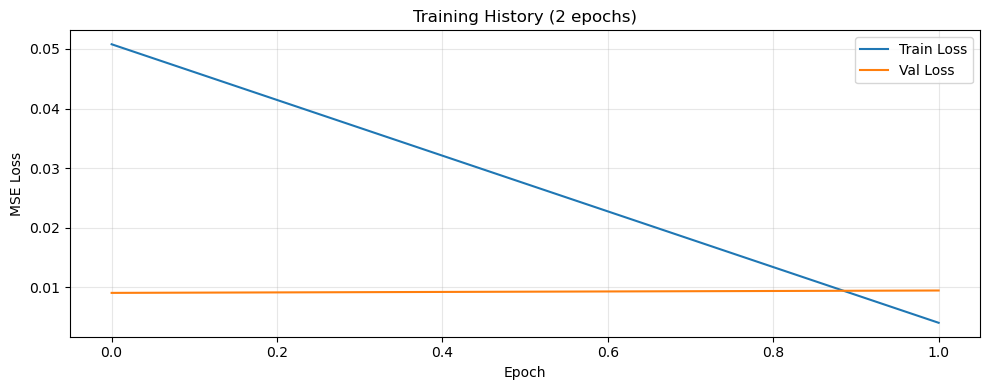


Best epoch: 1
Best val_loss: 0.009090


In [52]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

epochs_run = len(history.history['loss'])
ax.plot(history.history['loss'], label='Train Loss')
ax.plot(history.history['val_loss'], label='Val Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title(f'Training History ({epochs_run} epochs)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nBest epoch: {np.argmin(history.history['val_loss']) + 1}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

## 7. Test Prediction (Full Domain)

Load one test frame and predict on the full domain to verify the model works.

In [61]:
# Load one test day for full-domain prediction
test_date = str(min(val_end_date + pd.Timedelta(days=15), pd.to_datetime(ds.time.values[-1])).date())
print(f"Test prediction date: {test_date}")

# Select and load test frame
ds_test = ds_std.sel(time=test_date).load()

# Stack channels
X_test = np.stack(
    [np.nan_to_num(ds_test[ch].values, nan=0.0) for ch in X_vars],
    axis=-1,
).astype('float32')
X_test = X_test[np.newaxis, ...]  # Add batch dimension

print(f"Test input shape: {X_test.shape}")

# Predict (fully-convolutional model handles any size)
y_pred = model(X_test, training=False).numpy()[0, :, :, 0]

# Unstandardize
y_pred_orig = y_pred * y_std + y_mean

print(f"Prediction shape: {y_pred_orig.shape}")
print(f"Prediction range: [{np.nanmin(y_pred_orig):.4f}, {np.nanmax(y_pred_orig):.4f}]")
print("\n✓ Model successfully predicts on full domain")

Test prediction date: 1997-12-18
Test input shape: (1, 128, 128, 9)
Prediction shape: (128, 128)
Prediction range: [-0.1227, 0.1408]

✓ Model successfully predicts on full domain


/tmp/ipykernel_13650/1220469269.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


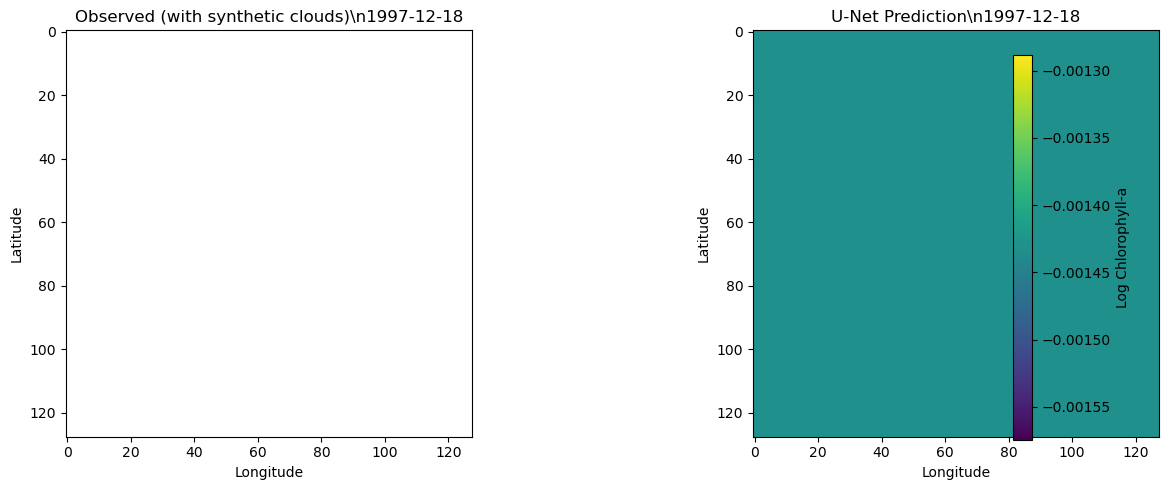

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Observed (with synthetic gaps)
observed = ds_test['masked_target'].values
axes[0].imshow(observed, cmap='viridis', origin='upper')
axes[0].set_title(f'Observed (with synthetic clouds)\\n{test_date}')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

# Prediction
im = axes[1].imshow(y_pred_orig, cmap='viridis', origin='upper')
axes[1].set_title(f'U-Net Prediction\\n{test_date}')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.colorbar(im, ax=axes, label='Log Chlorophyll-a', fraction=0.02)
plt.tight_layout()
plt.show()

## 8. Save Model

Save the trained model for later use.

In [56]:
product_ids = {
    1: "PACE_OCI_L3M_CHL",
    2: "cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D",
    3: "mind_the_chl_gap/IO_rechunked.zarr",
    4: "mindthegap-demo",
}
standardization = {}
for name in [*X_vars, "full_target"]:
    values = stats.get(name, (0.0, 1.0))
    standardization[name] = {
        "mean": values[0],
        "std": values[1],
        "applied": name in stats,
    }
bundle_name = dataset_names[dataset].lower().replace(" ", "-")
bundle_path = Path("../models") / f"{bundle_name}-unet-bundle"
metadata_path = mtg.create_model_bundle_metadata(
    bundle_path,
    model_name=f"{dataset_names[dataset]} U-Net gap filler",
    dataset_name=dataset_names[dataset],
    product_id=product_ids[dataset],
    region={
        "lat": [float(ds.lat.min()), float(ds.lat.max())],
        "lon": [float(ds.lon.min()), float(ds.lon.max())],
    },
    training_period=f"{train_start} to {train_end_date.date()}",
    input_names=X_vars,
    target_name=target_var,
    target_units=ds[target_var].attrs.get("units", "unknown"),
    expected_input_shape=list(model.input_shape),
    transforms={
        "target": "natural logarithm" if log_transform else "none",
        "temporal_lags": n_temporal_lags,
    },
    standardization=standardization,
    missing_value_handling=(
        "Missing predictor values are replaced with zero after "
        "standardization; mask channels identify land and missing data."
    ),
    limitations=(
        "Validated only for the documented product, region, training period, "
        "channel order, and preprocessing configuration."
    ),
    overwrite=True,
)
print(f"Metadata saved to: {metadata_path}")

Metadata saved to: ../models/globcolour-unet-bundle/model_metadata.yaml


### Stop and review the metadata

Open the `model_metadata.yaml` file printed above. Check the dataset, region, training period, input channel order, transforms, and standardization values. **Do not run the next cell until the metadata is correct.**

In [ ]:
mtg.save_model_bundle(
    model,
    bundle_path,
    overwrite=True,
)
print(f"✓ Model bundle saved to: {bundle_path}")

In [62]:
# Verify that the released artifact loads without rebuilding the U-Net.
loaded_model, loaded_metadata = mtg.load_model_bundle(bundle_path)
round_trip_input = X_test[:1]
expected = model(round_trip_input, training=False).numpy()
actual = loaded_model(round_trip_input, training=False).numpy()
np.testing.assert_allclose(actual, expected, rtol=1e-6, atol=1e-6)
assert [item["name"] for item in loaded_metadata["inputs"]] == X_vars
print("✓ Bundle reload produced equivalent predictions")

✓ Bundle reload produced equivalent predictions
